In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [18]:
batch_size = 128
latent_dim = 20
lr = 1e-3
epochs = 20
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

In [4]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

100.0%
100.0%
100.0%
100.0%


In [5]:
class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(28*28, 400),
            nn.ReLU()
        )

        self.fc_mu = nn.Linear(400, latent_dim)
        self.fc_logvar = nn.Linear(400, latent_dim)

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 400),
            nn.ReLU(),
            nn.Linear(400, 28*28),
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        x = x.view(-1, 28*28)
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar

In [6]:
def loss_function(recon_x, x, mu, logvar):
    x = x.view(-1, 28*28)

    # Reconstruction Loss (Binary Cross Entropy)
    recon_loss = nn.functional.binary_cross_entropy(recon_x, x, reduction='sum')

    # KL Divergence
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return recon_loss + kl_loss

In [7]:
model = VAE().to(device)
optimizer = optim.Adam(model.parameters(), lr=lr)

In [19]:
for epoch in range(epochs):
    model.train()
    total_loss = 0

    for data, _ in train_loader:
        data = data.to(device)

        optimizer.zero_grad()
        recon, mu, logvar = model(data)
        loss = loss_function(recon, data, mu, logvar)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss / len(train_loader.dataset):.4f}")

Epoch 1, Loss: 105.9024
Epoch 2, Loss: 105.5451
Epoch 3, Loss: 105.3413
Epoch 4, Loss: 105.0519
Epoch 5, Loss: 104.8924
Epoch 6, Loss: 104.6458
Epoch 7, Loss: 104.4537
Epoch 8, Loss: 104.2841
Epoch 9, Loss: 104.1594
Epoch 10, Loss: 103.9979
Epoch 11, Loss: 103.8791
Epoch 12, Loss: 103.7180
Epoch 13, Loss: 103.6378
Epoch 14, Loss: 103.4998
Epoch 15, Loss: 103.4239
Epoch 16, Loss: 103.3496
Epoch 17, Loss: 103.1825
Epoch 18, Loss: 103.1634
Epoch 19, Loss: 103.0387
Epoch 20, Loss: 102.9658


In [20]:
model.eval()

with torch.no_grad():
    z = torch.randn(64, latent_dim).to(device)
    samples = model.decode(z).cpu()
    samples = samples.view(64, 1, 28, 28)

In [21]:
import torchvision 
import matplotlib.pyplot as plt

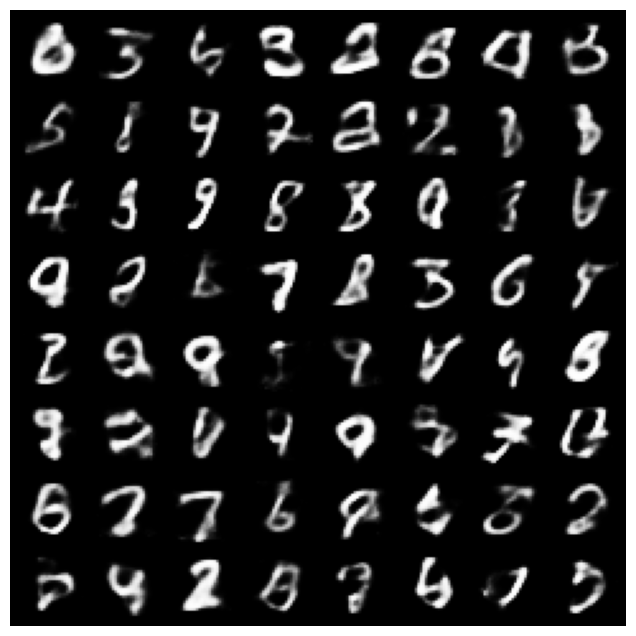

In [22]:
model.eval()

with torch.no_grad():
    z = torch.randn(64, 20).to(device)
    sample = model.decode(z).cpu()
    
    sample = sample.view(64, 1, 28, 28)

grid = torchvision.utils.make_grid(sample, nrow=8)

plt.figure(figsize=(8,8))
plt.imshow(grid.permute(1,2,0))
plt.axis('off')
plt.show()